In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df=pd.read_csv("real_delivery_data.csv")

In [3]:
df.head()

,order_id,Latitude,Longitude,Order_Value,Delivery_Time_Mins
0,e481f51cbdc54678b7cc49136f2d6af7,-23.576983,-46.587161,38.71,12148.666667
1,53cdb2fc8bc7dce0b6741e2150273451,-12.177924,-44.660711,141.46,19846.133333
2,47770eb9100c2d0c44946d9cf07ec65d,-16.745150,-48.514783,179.12,13527.666667
3,949d5b44dbf5de918fe9c16f97b45f8a,-5.774190,-35.271143,72.20,19020.600000
4,ad21c59c0840e6cb83a9ceb5573f8159,-23.676370,-46.514627,28.62,4138.383333


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96204 entries, 0 to 96203
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            96204 non-null  object 
 1   Latitude            96204 non-null  float64
 2   Longitude           96204 non-null  float64
 3   Order_Value         96204 non-null  float64
 4   Delivery_Time_Mins  96204 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.7+ MB


Checking Null Value

In [5]:
df.isnull().sum()

order_id              0
Latitude              0
Longitude             0
Order_Value           0
Delivery_Time_Mins    0
dtype: int64

In [6]:
df.describe()

,Latitude,Longitude,Order_Value,Delivery_Time_Mins
count,96204.000000,96204.000000,96204.000000,96204.000000
mean,-21.205018,-46.189920,159.824916,18069.831811
std,5.588871,4.050806,218.860250,13739.262293
min,-33.689948,-72.668881,9.590000,768.116667
25%,-23.589908,-48.118559,61.840000,9733.066667
50%,-22.924970,-46.632056,105.280000,14703.133333
75%,-20.140216,-43.625086,176.230000,22612.712500
max,3.842508,-34.725130,13664.080000,301865.200000


In [7]:
df.drop(["order_id"],axis=1,inplace=True)

Performing EDA here


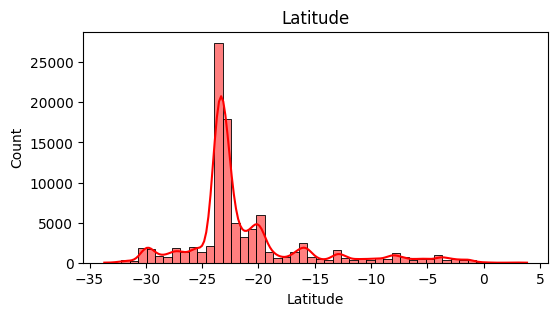

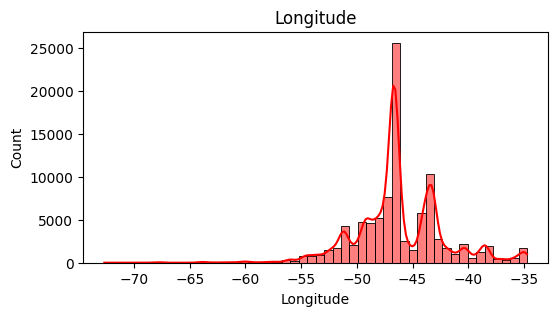

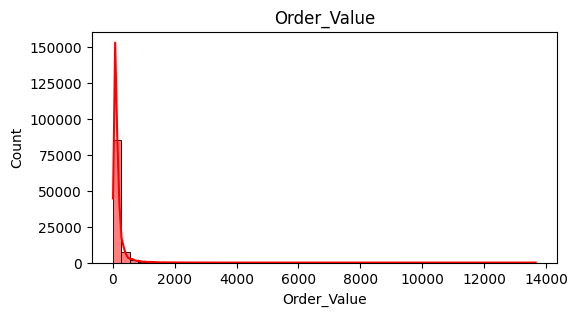

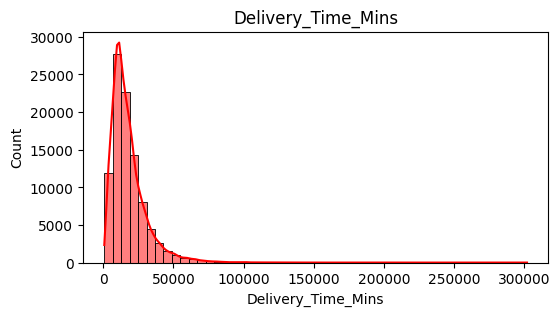

In [8]:
num_features=df.select_dtypes(exclude="object").columns
for features in num_features:
    plt.figure(figsize=(6,3))
    sns.histplot(df[features],bins=50,color='red',kde=True)
    plt.title(features)
    plt.show()

Delivery_Time_Mins (The Logistics Nightmare)
Extreme right skew. Most deliveries happen in the first massive lump, but look at the X-axis—it stretches all the way to 300,000 minutes.
300,000 minutes is over 200 days! In the real world, packages get lost in the mail, held up at customs, or sit in a warehouse completely forgotten.

Order_Value(The Financial Skew)
 A severe right skew. The bulk of the data is crushed against the left side (under 1,000), but there is a microscopic tail extending all the way out to 14,000.
 Most people buy standard, low-cost items online. However, there are a few rare, massive B2B orders or high-value electronics in the dataset.

 This real-world dataset has a severe right skew in both value and time, We must apply the Log Transform to both columns before feeding them to the Isolation Forest.

 If we pass this raw data into the anomaly detector as-is, the algorithm will get completely blinded by those 200-day delays and fail to catch the actual subtle fraud cases.

In [9]:
df["Order_Value"]=np.log1p(df["Order_Value"])
df["Delivery_Time_Mins"]=np.log1p(df["Delivery_Time_Mins"])


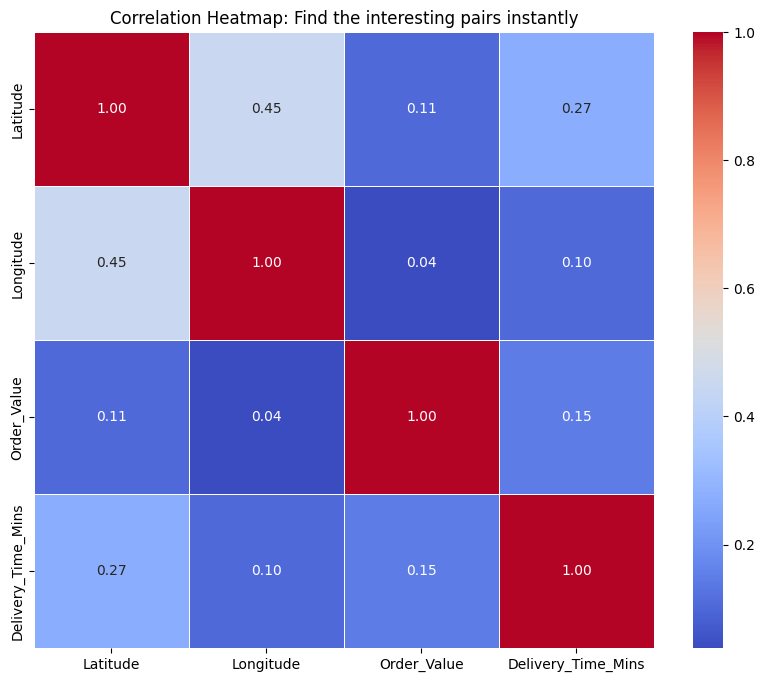

In [10]:
plt.figure(figsize=(10, 8))

correlation_matrix = df[['Latitude', 'Longitude', 'Order_Value', 'Delivery_Time_Mins']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Find the interesting pairs instantly')
plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [12]:
scaled_data=scaler.fit_transform(df)

In [13]:
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN

In [14]:
iso_fores=IsolationForest(contamination=0.01,random_state=42)
anomaly_labels=iso_fores.fit_predict(scaled_data)
df['Anomaly_Label'] = anomaly_labels
print("Isolation Forest Results:")
print(df['Anomaly_Label'].value_counts())

Isolation Forest Results:
Anomaly_Label
 1    95241
-1      963
Name: count, dtype: int64


now we have to remove anomalies from scaled data

In [15]:
clean=df["Anomaly_Label"]==1
clean_scaled_data=scaled_data[clean]

In [16]:
dbscan=DBSCAN(eps=0.2,min_samples=5)
cluster_labels = dbscan.fit_predict(clean_scaled_data)
# We will set a default of -2 for the anomalies so they don't get mixed up with DBSCAN's noise (-1)
df['Cluster'] = -2 
df.loc[clean, 'Cluster'] = cluster_labels

In [17]:
print("DBSCAN Clustering Results (Number of orders per zone):")
print(df['Cluster'].value_counts())

DBSCAN Clustering Results (Number of orders per zone):
Cluster
 0      75389
-1      12109
 2       1943
 3       1840
-2        963
        ...  
 127        3
 188        3
 181        3
 270        2
 281        2
Name: count, Length: 288, dtype: int64


Now Hypertuning the dbscan

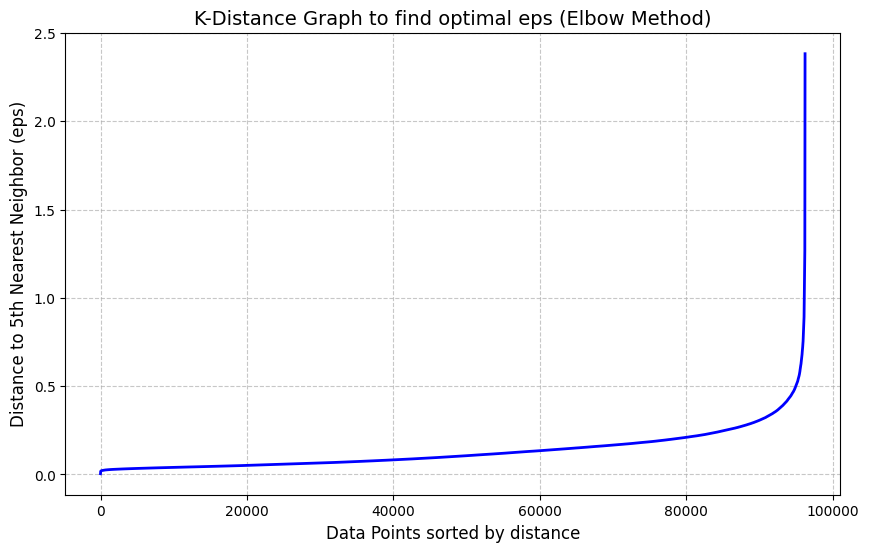

In [18]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5).fit(scaled_data)
distances, indices = nn.kneighbors(scaled_data)


k_distances = np.sort(distances[:, -1])
plt.figure(figsize=(10, 6))
plt.plot(k_distances, color='blue', linewidth=2)

plt.title('K-Distance Graph to find optimal eps (Elbow Method)', fontsize=14)
plt.xlabel('Data Points sorted by distance', fontsize=12)
plt.ylabel('Distance to 5th Nearest Neighbor (eps)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

so eps=0.4

In [19]:
dbscan=DBSCAN(eps=0.4,min_samples=5)
cluster_labels = dbscan.fit_predict(clean_scaled_data)
# We will set a default of -2 for the anomalies so they don't get mixed up with DBSCAN's noise (-1)
df['Cluster'] = -2 
df.loc[clean, 'Cluster'] = cluster_labels
print("DBSCAN Clustering Results After Hyperparameter Tuning (Number of orders per zone):")
print(df['Cluster'].value_counts())

DBSCAN Clustering Results After Hyperparameter Tuning (Number of orders per zone):
Cluster
 0     93848
-1      1202
-2       963
 5        32
 10       27
 1        15
 7        12
 15       12
 12        7
 8         6
 4         6
 16        6
 3         6
 6         6
 11        6
 20        6
 2         5
 21        5
 9         5
 19        5
 14        5
 18        5
 17        5
 22        5
 13        4
Name: count, dtype: int64


DBSCAN is brilliant at finding organic shapes, but terrible at assigning quotas. Because our primary business goal is to divide the country into actionable, evenly distributed logistics zones, K-Means is the superior algorithm here.

K-Means does not care if the data is connected by a highway. If we tell K-Means to build exactly 5 zones (k=5), it will drop 5 center points on the map and slice that 90,000-point Mega-Cluster into 5 rigid, distinct warehouse territories.

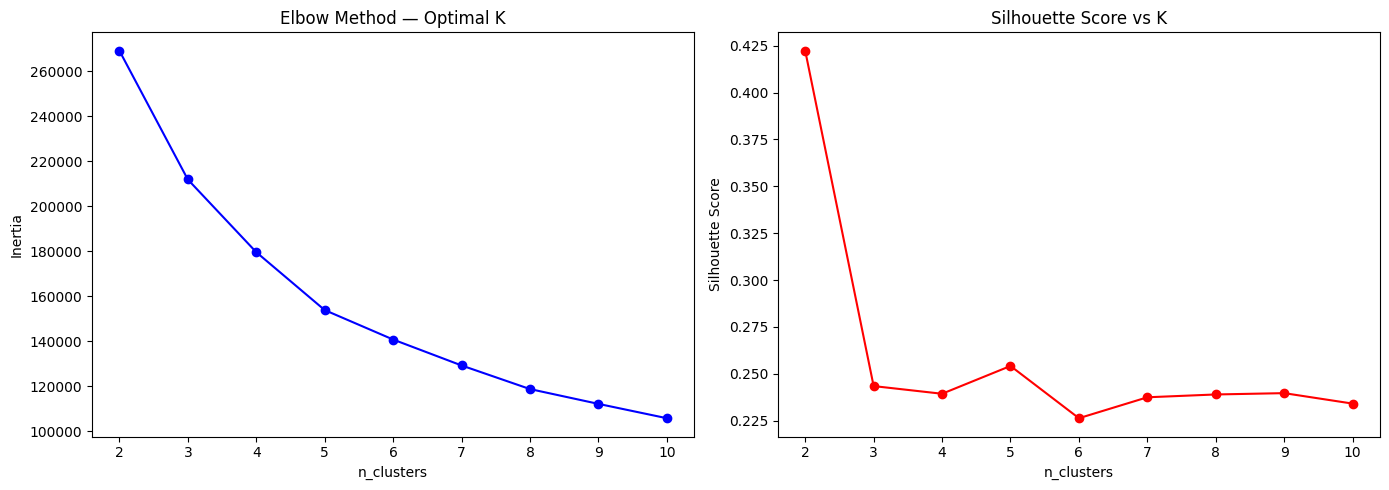

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

inertias = []
sil_scores = []

K_range = range(2, 11)

for k in K_range:
    km_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_test = km_test.fit_predict(clean_scaled_data)

    inertias.append(km_test.inertia_)
    sil_scores.append(
        silhouette_score(clean_scaled_data, labels_test, sample_size=5000, random_state=42)
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_range), inertias, 'bo-')
ax1.set_title('Elbow Method — Optimal K')
ax1.set_xlabel('n_clusters')
ax1.set_ylabel('Inertia')

ax2.plot(list(K_range), sil_scores, 'ro-')
ax2.set_title('Silhouette Score vs K')
ax2.set_xlabel('n_clusters')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('elbow_plot.png')
plt.show()

In [23]:
sil = silhouette_score(clean_scaled_data, cluster_labels, sample_size=5000, random_state=42)
db  = davies_bouldin_score(clean_scaled_data, cluster_labels)
print(f"Silhouette Score  : {sil:.4f}  (higher = better, max 1.0)")
print(f"Davies-Bouldin    : {db:.4f}  (lower  = better, min 0.0)")

Silhouette Score  : 0.0713  (higher = better, max 1.0)
Davies-Bouldin    : 1.2453  (lower  = better, min 0.0)


In [24]:
# Forcing exactly 5 logistics zones
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(clean_scaled_data)

df['Cluster'] = -2 
df.loc[clean, 'Cluster'] = cluster_labels

print("\nK-Means Logistics Zones (Orders per Warehouse):")
print(df['Cluster'].value_counts())


K-Means Logistics Zones (Orders per Warehouse):
Cluster
 2    25904
 4    25704
 0    20159
 3    14107
 1     9367
-2      963
Name: count, dtype: int64


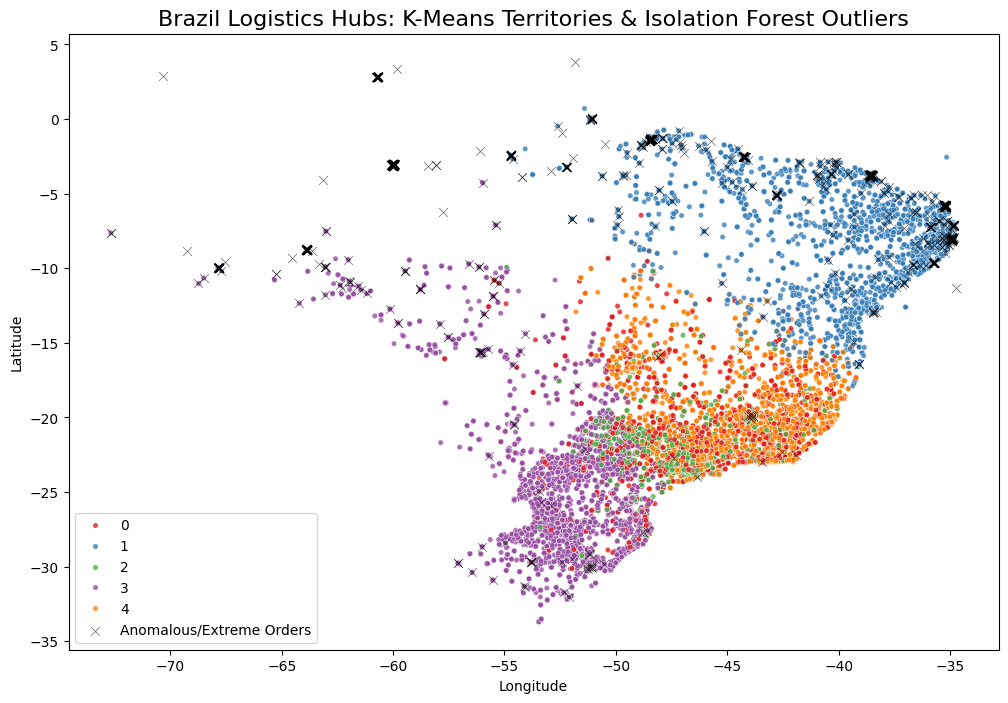

In [25]:

plt.figure(figsize=(12, 8))

# Ploting the 5 K-Means Delivery Zones
valid_clusters = df[df['Cluster'] >= 0]
sns.scatterplot(
    x='Longitude', y='Latitude', 
    hue='Cluster', data=valid_clusters, 
    palette='Set1', s=15, alpha=0.8, legend='full'
)

# Ploting the 4,811 Anomalies caught by Isolation Forest
anomalies = df[df['Anomaly_Label'] == -1]
sns.scatterplot(
    x='Longitude', y='Latitude', 
    data=anomalies, 
    color='black', marker='x', s=40, alpha=0.6, label='Anomalous/Extreme Orders'
)

plt.title('Brazil Logistics Hubs: K-Means Territories & Isolation Forest Outliers', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()